# Explortory Data Analysis (EDA)

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# importing the cleaned dataset

df = pd.read_csv('../data/creditcard_cleaned.csv')

In [4]:
# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')


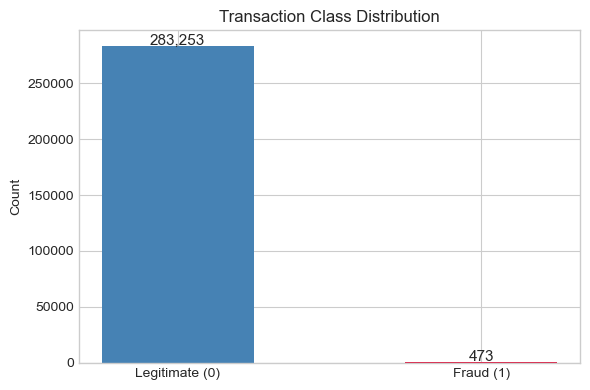

Plot saved.


In [5]:
#Shows the imbalance problem visually
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Class'].value_counts()
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
              color=['steelblue', 'crimson'], width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}', ha='center', fontsize=11)
ax.set_title('Transaction Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150)
plt.show()
print("Plot saved.")

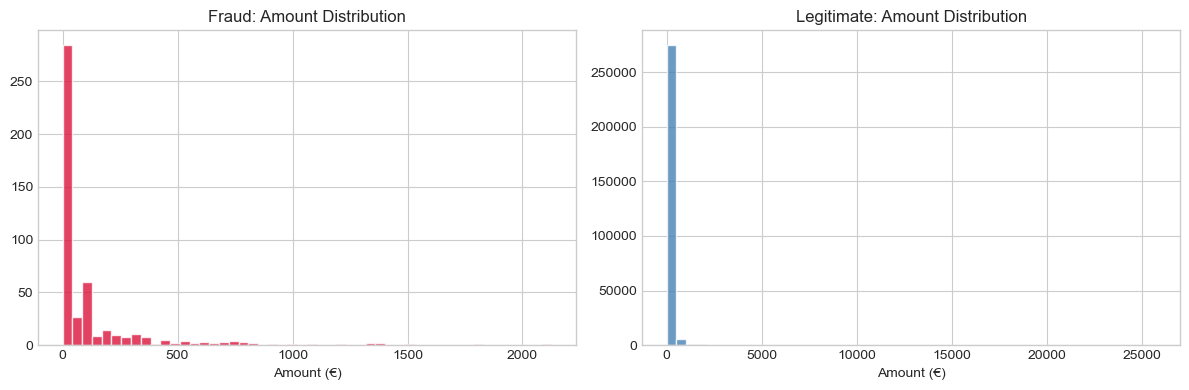


Avg fraud amount:    €123.87
Avg legit amount:    €88.41
Max fraud amount:    €2125.87


In [7]:
#Fraudulent transactions may differ in amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

axes[0].hist(fraud['Amount'], bins=50, color='crimson', alpha=0.8, edgecolor='white')
axes[0].set_title('Fraud: Amount Distribution')
axes[0].set_xlabel('Amount (€)')

axes[1].hist(legit['Amount'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Legitimate: Amount Distribution')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('../reports/02_amount_distribution.png', dpi=150)
plt.show()

print(f"\nAvg fraud amount:    €{fraud['Amount'].mean():.2f}")
print(f"Avg legit amount:    €{legit['Amount'].mean():.2f}")
print(f"Max fraud amount:    €{fraud['Amount'].max():.2f}")

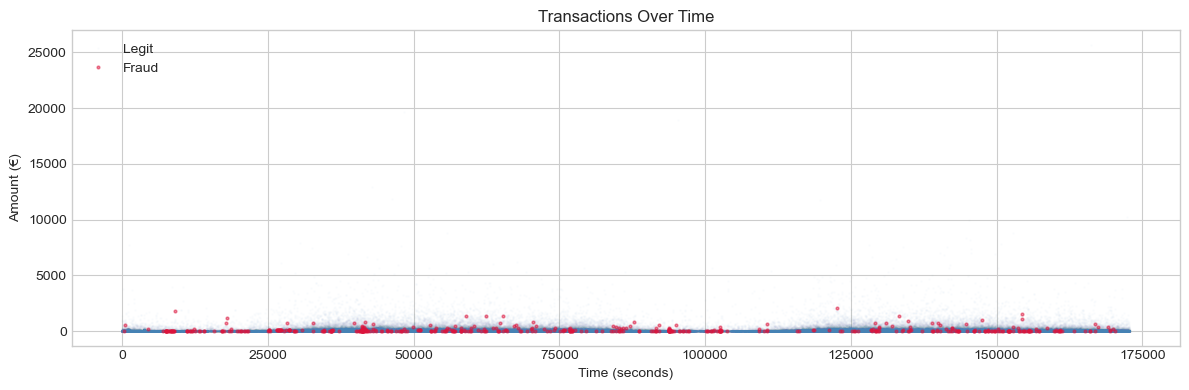

In [8]:
#Fraud may cluster at certain hours
plt.figure(figsize=(12, 4))
plt.plot(df[df['Class'] == 0]['Time'], df[df['Class'] == 0]['Amount'],
         '.', alpha=0.01, color='steelblue', label='Legit', markersize=2)
plt.plot(df[df['Class'] == 1]['Time'], df[df['Class'] == 1]['Amount'],
         '.', alpha=0.5, color='crimson', label='Fraud', markersize=4)
plt.xlabel('Time (seconds)')
plt.ylabel('Amount (€)')
plt.title('Transactions Over Time')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/03_time_analysis.png', dpi=150)
plt.show()

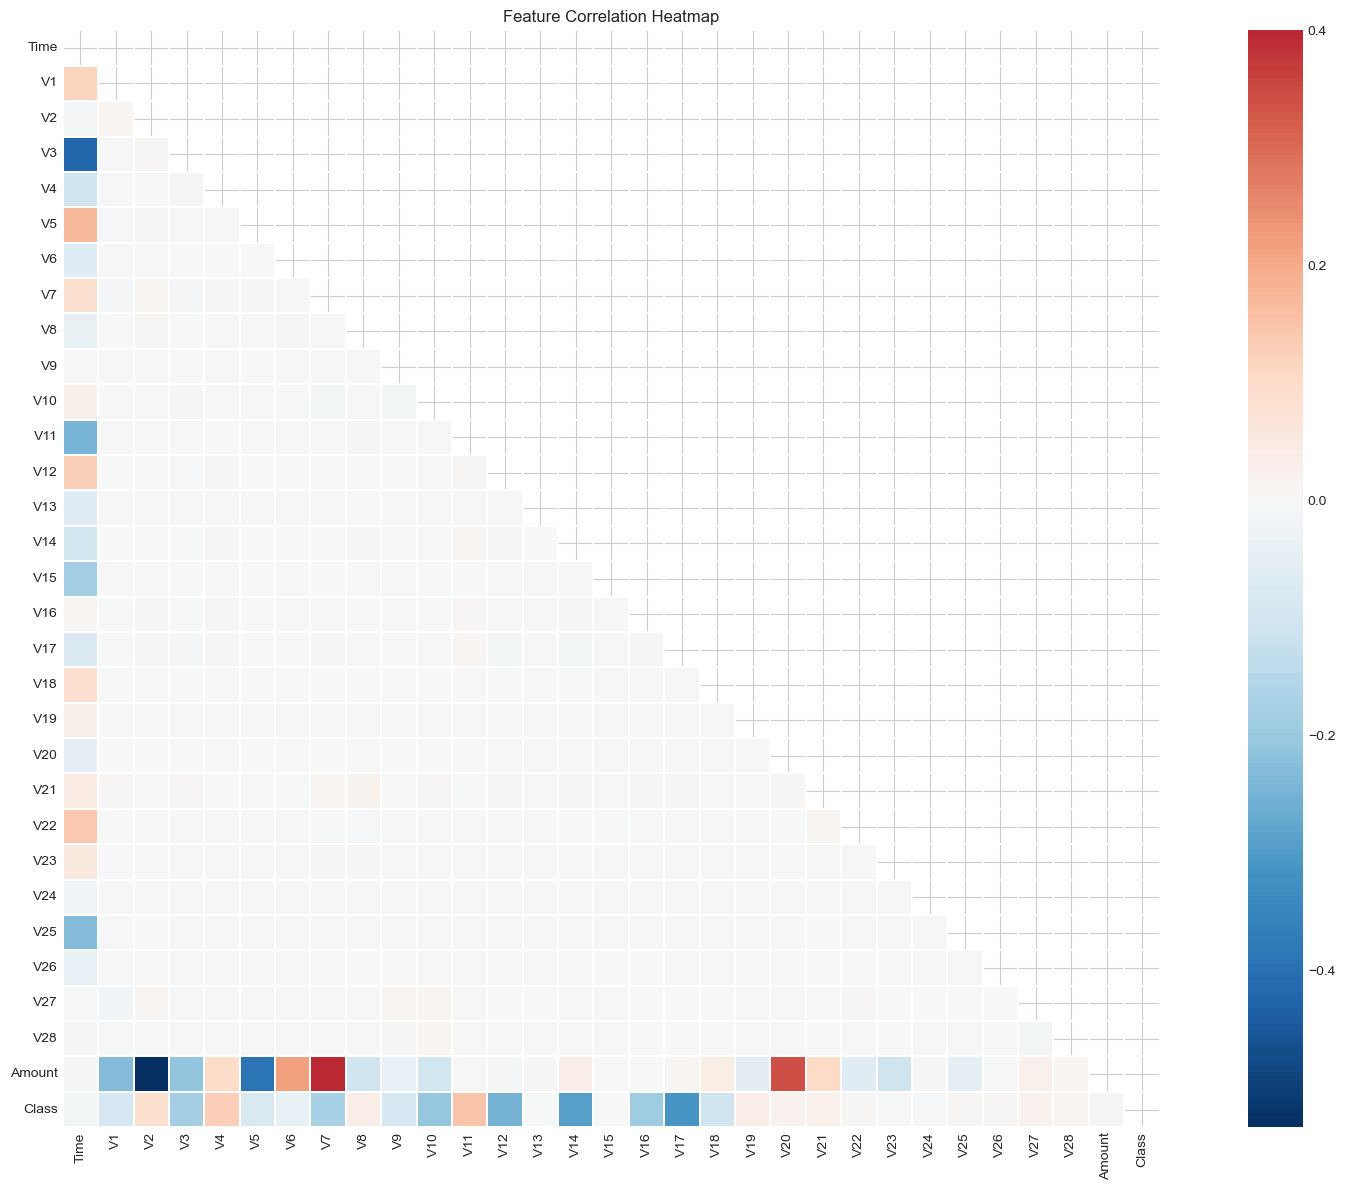

In [9]:
#Find features that correlate with fraud (Class = 1)
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
# Print top features correlated with Class
print("\nTop features correlated with fraud:")
print(corr_matrix['Class'].sort_values(ascending=False).head(10))



Top features correlated with fraud:
Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


In [11]:
print("\n=== KEY BUSINESS INSIGHTS ===")
print(f"1. Only {len(fraud)} out of {len(df)} transactions are fraud ({len(fraud)/len(df)*100:.2f}%)")
print(f"2. Average fraud amount: €{fraud['Amount'].mean():.2f} vs legit: €{legit['Amount'].mean():.2f}")
print(f"3. Max fraud amount: €{fraud['Amount'].max():.2f}")
print(f"4. Most fraud happens in amounts under €2,500")


=== KEY BUSINESS INSIGHTS ===
1. Only 473 out of 283726 transactions are fraud (0.17%)
2. Average fraud amount: €123.87 vs legit: €88.41
3. Max fraud amount: €2125.87
4. Most fraud happens in amounts under €2,500
